# QF 627 Programming and Computational Finance
## Problem Set `4` | `Questions`

> "Hi Team! 👋

> The current notebook contains 8 questions that help you review our course content.

> Each question asks you to answer with specific results. Some questions are the `reverse-engineering-type` questions as I have asked in exercise problem set 3. Other questions require direct answers (because, given the nature of the question, reverse-engineering is not feasible).

> These questions won’t be difficult to solve—and working through them will strengthen your understanding of the learning materials. This week’s questions ask you to preview the lecture note script for Lesson 4, which we will continue in Lesson 5, and then attempt to answer the exercises.

> This preview exercise will help you consolidate the upcoming lessons more effectively. Once you have completed it, please submit your script via eLearn.

> Enjoy!"

##### First, let's do some quick exercise with stock prices data.

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [2]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

### <font color = red> Question 1</font>. Please import historical stock data from the web on the following financial instruments, and create the following DataFrame that contains adjusted closing prices. 

### Here, the timeframe should be set between the 13th of October 2014 through the 13th of September 2022 (nine years of data).

- `WMT` Stock of Walmart
- `IBM` Stock of IBM

In [3]:
# df =\
# yf.download(['WMT','IBM'],
#             start=dt.datetime(2014,10,13),
#             end=dt.datetime(2022,9,22))['Close']
df =\
yf.download(['WMT', 'IBM'], 
            auto_adjust = False,
            start = '2014-10-13',
            end = '2022-09-14')['Adj Close']

[*********************100%***********************]  2 of 2 completed


In [4]:
df

Ticker,IBM,WMT
Date,,
2014-10-13,110.969650,20.890911
2014-10-14,111.138962,21.004047
2014-10-15,109.899391,20.255245
2014-10-16,108.744453,19.883541
2014-10-17,110.080788,19.958965
...,...,...
2022-09-07,113.740059,43.546246
2022-09-08,114.416939,43.767601
2022-09-09,115.058174,43.899143


### <font color = red> Question 2</font>. Please run a simple moving average crossover strategy for `IBM`.

### The two moving windows are 20 and 60 days.

### Please show your positions with a plot.

### <mark> What is shown below is a sample to illustrate the type of visualization you should display; the results you obtain may not necessarily be the same.</mark>

In [5]:
ibm =\
(
    df[['IBM']]
)

In [6]:
ibm

Ticker,IBM
Date,
2014-10-13,110.969650
2014-10-14,111.138962
2014-10-15,109.899391
2014-10-16,108.744453
2014-10-17,110.080788
...,...
2022-09-07,113.740059
2022-09-08,114.416939
2022-09-09,115.058174


In [7]:
def enrich_sma(df, sma_list):
    """
    Take DF and given list of SMA to enrich df when stock price is in first column
    """
    for window in sma_list:
        df[f"sma_{window}"] =\
        (
            df[df.columns[0]]
            .rolling(window = window)
            .mean()
        )

    return df

In [8]:
sma = [20, 60]

# for window in sma:
#     ibm[f"sma_{window}"] =\
#     (
#         ibm['IBM']
#         .rolling(window = window)
#         .mean()
#     )
ibm = enrich_sma(ibm, sma)

In [9]:
ibm =\
ibm.dropna()

In [10]:
def enrich_signal_sma_cross(df, fast_ln_col, slow_ln_col, bullish_signal=1, bearish_signal=-1):
    """
    Take DF and given column names of SMA to enrich df with signal 
    if fast_ln_col >  slow_ln_col then bullish_signal
    else fast_ln_col <  slow_ln_col then bearish_signal

    """
    df['signal'] =\
    (
        np.where(df[fast_ln_col]>df[slow_ln_col],bullish_signal,bearish_signal)
    )

    return df

In [11]:
enrich_signal_sma_cross(ibm, fast_ln_col='sma_20', slow_ln_col='sma_60')

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53634/3671954840.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['signal'] =\


Ticker,IBM,sma_20,sma_60,signal
Date,,,,
2015-01-07,94.396317,96.620592,99.068448,-1
2015-01-08,96.447975,96.481479,98.826420,-1
2015-01-09,96.868073,96.438861,98.588572,-1
2015-01-12,95.242523,96.297919,98.344291,-1
2015-01-13,95.467804,96.341450,98.123013,-1
...,...,...,...,...
2022-09-07,113.740059,118.133903,118.805318,-1
2022-09-08,114.416939,117.998975,118.731711,-1
2022-09-09,115.058174,117.849798,118.659848,-1


In [12]:
ibm['signal'] =\
(
    np.where(ibm.sma_20>ibm.sma_60,1,-1)
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53634/1773197279.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ibm['signal'] =\


<Axes: xlabel='Date'>

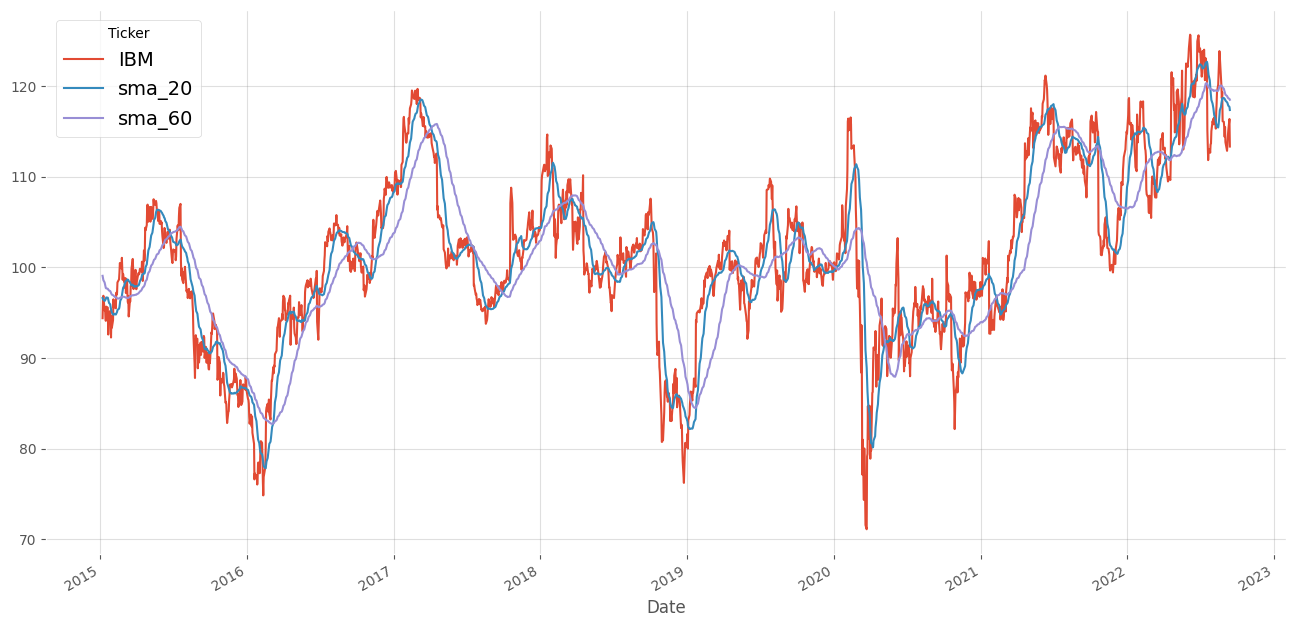

In [13]:
ibm[ibm.columns[:-1]].plot(figsize=[16,8])

<Axes: xlabel='Date'>

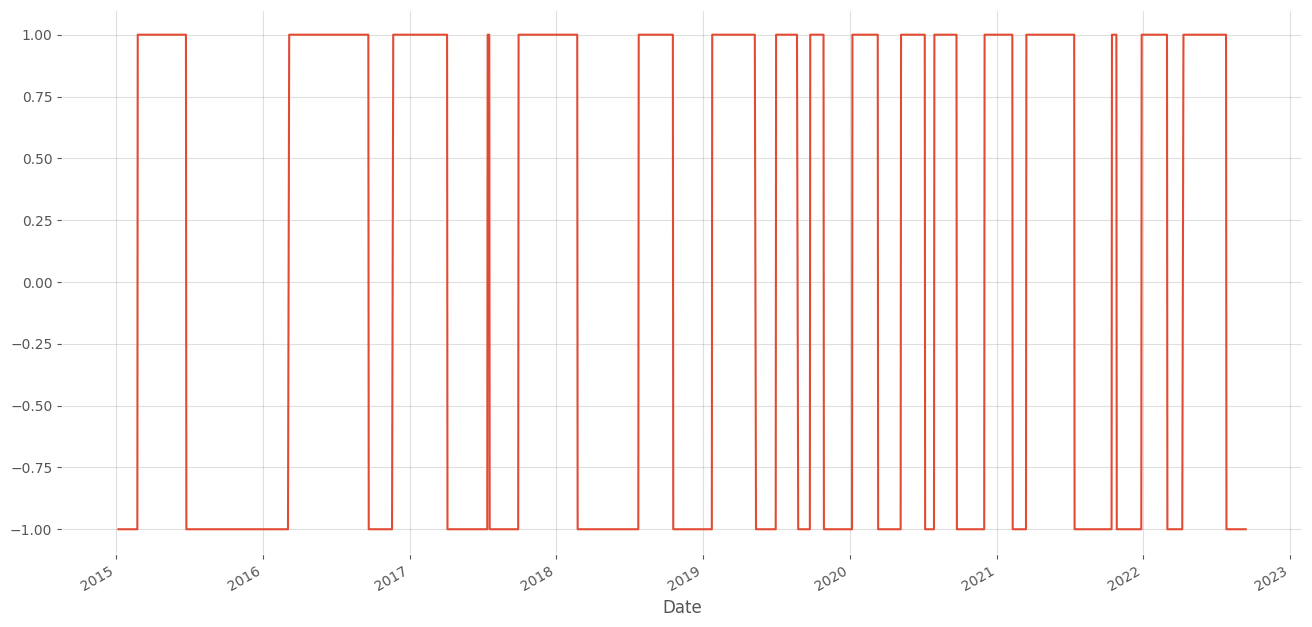

In [14]:
ibm[ibm.columns[-1]].plot(figsize=[16,8])

In [15]:
from lets_plot import *
LetsPlot.setup_html()

In [16]:
ibm.reset_index()

Ticker,Date,IBM,sma_20,sma_60,signal
0,2015-01-07,94.396317,96.620592,99.068448,-1
1,2015-01-08,96.447975,96.481479,98.826420,-1
2,2015-01-09,96.868073,96.438861,98.588572,-1
3,2015-01-12,95.242523,96.297919,98.344291,-1
4,2015-01-13,95.467804,96.341450,98.123013,-1
...,...,...,...,...,...
1930,2022-09-07,113.740059,118.133903,118.805318,-1
1931,2022-09-08,114.416939,117.998975,118.731711,-1
1932,2022-09-09,115.058174,117.849798,118.659848,-1
1933,2022-09-12,116.367378,117.700621,118.590164,-1


In [17]:
(
    ggplot(ibm,
           aes(x = "DATE")
          )
    + geom_line(aes(y = "price"),
                color = "grey",
                alpha = 0.50
               )
    + geom_line(aes(y = "sma_40"),
                color = "red"
               )
    + geom_line(aes(y = "sma_250"),
                color = "darkgreen")
    + ggsize(1200, 400)
    + labs(title = "US/EU Exchange Rates, along with 40- and 250-day MAs",
           y = "US/EU Exchange Rates")
)

<Axes: xlabel='Date'>

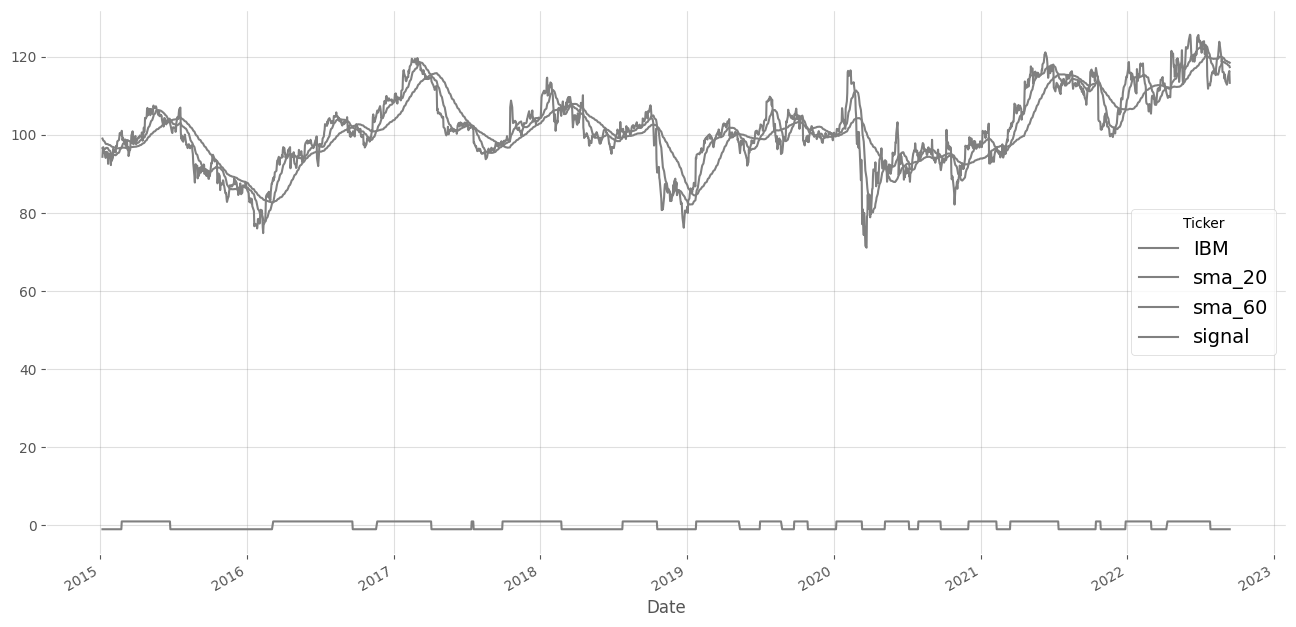

In [18]:
ibm.plot(figsize=[16,8],color='grey')

<Axes: xlabel='Date'>

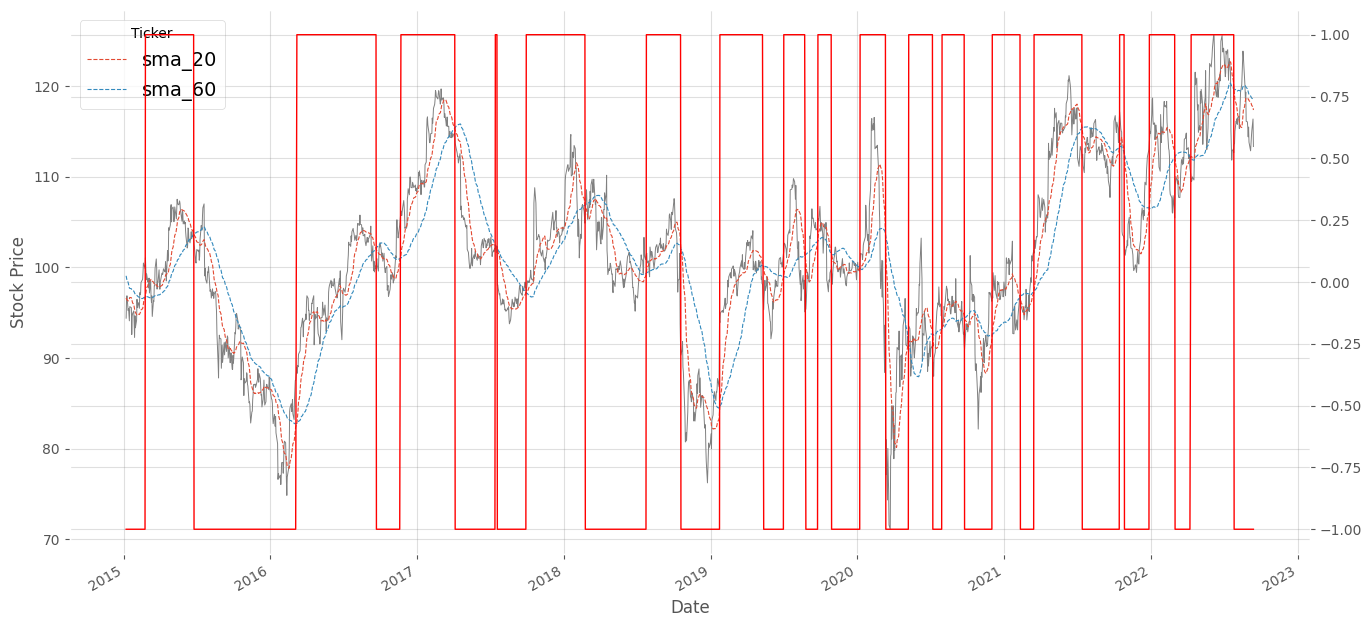

In [19]:
f =\
(
    plt
    .figure(figsize = [16,8]
           )
)

sub=\
(
    f
    .add_subplot(111,
                 ylabel = "Stock Price")
)

# Price Action (Daily)

(
    ibm
    ["IBM"]
    .plot(ax = sub,
          lw = 0.70,
          color = "grey")
)

# Moving Averages(Shorter vs. Longer)

(
    ibm
    [["sma_20", "sma_60"]]
    .plot(ax = sub,
          lw = 0.80,
          style = ["--", "--"]
         )
)

# plot signals
sub2 = sub.twinx()

(
    ibm['signal']
    .plot(ax= sub2,
          lw = 1,
          style = ["-"],
          color = "red"
    )
)


### <font color = red> Question 3</font>. Based on your lines of codes that lead to answer 2 above, compare the returns to see if the strategy leads to a win over the passive benchmark investment.

In [20]:
ibm

Ticker,IBM,sma_20,sma_60,signal
Date,,,,
2015-01-07,94.396317,96.620592,99.068448,-1
2015-01-08,96.447975,96.481479,98.826420,-1
2015-01-09,96.868073,96.438861,98.588572,-1
2015-01-12,95.242523,96.297919,98.344291,-1
2015-01-13,95.467804,96.341450,98.123013,-1
...,...,...,...,...
2022-09-07,113.740059,118.133903,118.805318,-1
2022-09-08,114.416939,117.998975,118.731711,-1
2022-09-09,115.058174,117.849798,118.659848,-1


In [21]:
def enrich_passive_strategy_ret(df):
    """
    gives df of enriched df with passive as strt ret also cum ret
    ASSUMES 
    - columns[0] is ticker data
    - 'signal' columns is present

    """

    df['pass_ret'] =\
    (
        np.log(
            df[df.columns[0]] / df[df.columns[0]].shift(1)
            )
    )
    df['strt_ret'] =\
    (
        df['pass_ret'] * df['signal'].shift(1)
    )
    df['pass_cum_ret'] =\
    (
        np.log(
            df[df.columns[0]] / df[df.columns[0]].shift(1)
            )
    ).cumsum().apply(np.exp)
    df['strt_cum_ret'] =\
    (
        df['pass_ret'] * df['signal'].shift(1)
    ).cumsum().apply(np.exp)

    return df

In [22]:
ibm['pass_ret'] =\
(
    np.log(
        ibm['IBM'] / ibm['IBM'].shift(1)
        )
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53634/3538907633.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ibm['pass_ret'] =\


In [23]:
ibm['strt_ret'] =\
(
    ibm['pass_ret'] * ibm['signal'].shift(1)
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53634/1663569447.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ibm['strt_ret'] =\


<Axes: xlabel='Date'>

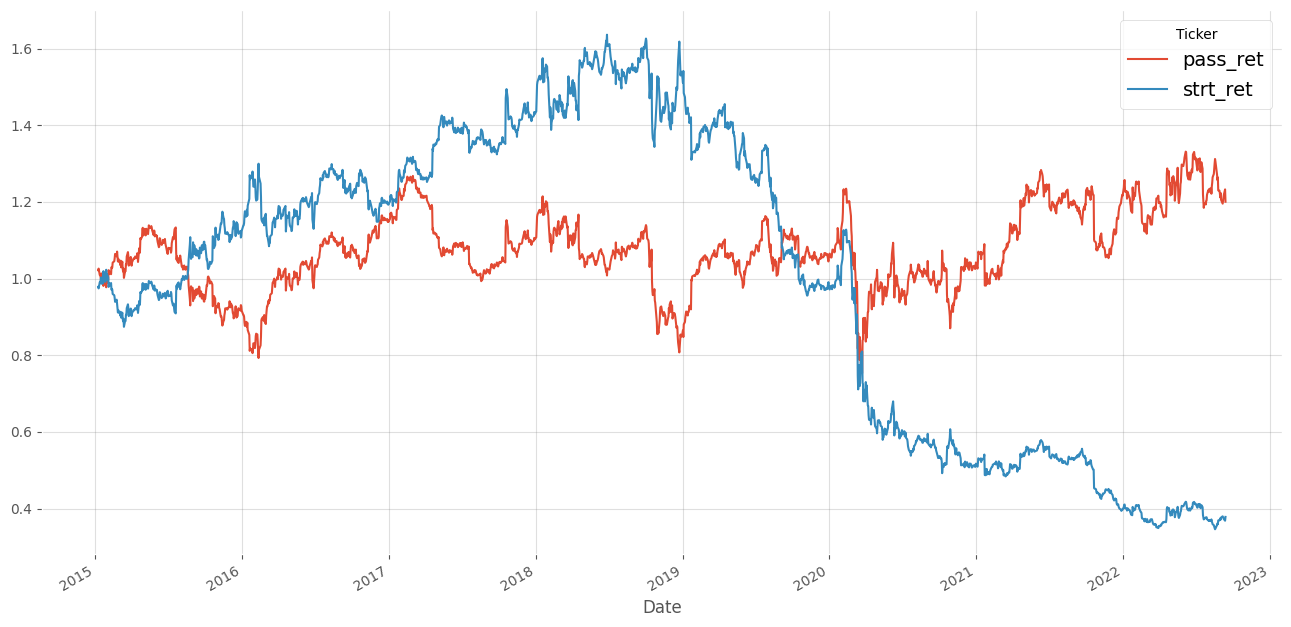

In [24]:
ibm[ibm.columns[-2:]].cumsum().apply(np.exp).plot(figsize=[16,8])

### <font color = red> Question 4</font>. Based on your lines of codes that lead to answer 3 above, please calculate the maximum drawdown and the longest drawdown period.

In [25]:
ibm.columns[-1]

'strt_ret'

In [26]:
ibm['cum_ret'] =\
(
    ibm[ibm.columns[-1]].cumsum().apply(np.exp)
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53634/4123529830.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ibm['cum_ret'] =\


In [27]:
ibm['max_cum_ret'] =\
(
    ibm.cum_ret.cummax()
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53634/863550636.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ibm['max_cum_ret'] =\


<Axes: xlabel='Date'>

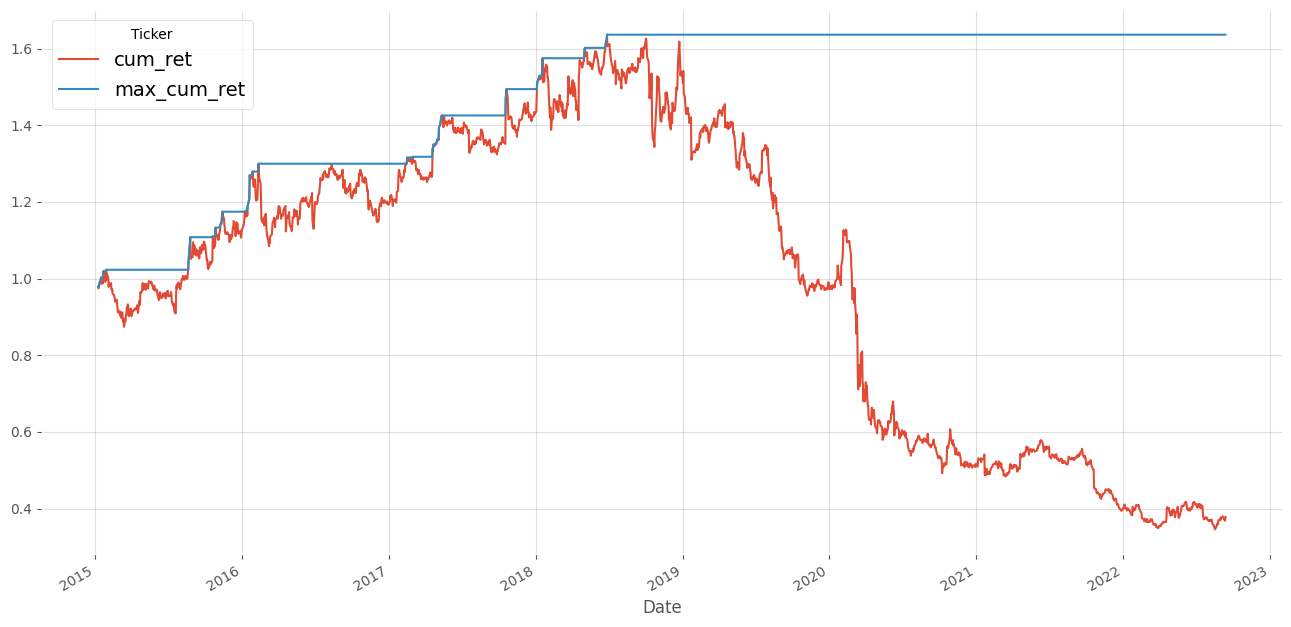

In [28]:
ibm[ibm.columns[-2:]].plot(figsize=[16,8])

THIS SHOULD BE DAILY DRAW DOWN NOT MAX DRAW DOWN

In [29]:
ibm['max_drawdown'] =\
(
    ibm['cum_ret'] / ibm['max_cum_ret'] - 1
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53634/1627177911.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ibm['max_drawdown'] =\


In [30]:
ibm['max_drawdown']

Date
2015-01-07         NaN
2015-01-08    0.000000
2015-01-09   -0.004337
2015-01-12    0.000000
2015-01-13   -0.002360
                ...   
2022-09-07   -0.769629
2022-09-08   -0.770991
2022-09-09   -0.772268
2022-09-12   -0.774830
2022-09-13   -0.768796
Name: max_drawdown, Length: 1935, dtype: float64

In [31]:
ibm['max_cum_ret']\
    .groupby(ibm['max_cum_ret'].values)\
        .count()\
            .sort_values(ascending=False).head()

1.636358    1061
1.299823     254
1.023095     142
1.425665     110
1.574997      72
Name: max_cum_ret, dtype: int64

In [32]:
ibm['max_drawdown'].min()

np.float64(-0.7884466142307873)

In [33]:
print(f"    The maximum drawdown is about {ibm['max_drawdown'].min() * 100:-2f} percentage points.")
print(f"The longest drawdown period lasts for {ibm['max_cum_ret']\
    .groupby(ibm['max_cum_ret'].values)\
        .count()\
            .sort_values(ascending=False).iloc[0]} days.")

    The maximum drawdown is about -78.844661 percentage points.
The longest drawdown period lasts for 1061 days.


In [34]:
ibm

Ticker,IBM,sma_20,sma_60,signal,pass_ret,strt_ret,cum_ret,max_cum_ret,max_drawdown
Date,,,,,,,,,
2015-01-07,94.396317,96.620592,99.068448,-1,NaN,NaN,NaN,NaN,NaN
2015-01-08,96.447975,96.481479,98.826420,-1,0.021502,-0.021502,0.978728,0.978728,0.000000
2015-01-09,96.868073,96.438861,98.588572,-1,0.004346,-0.004346,0.974483,0.978728,-0.004337
2015-01-12,95.242523,96.297919,98.344291,-1,-0.016923,0.016923,0.991115,0.991115,0.000000
2015-01-13,95.467804,96.341450,98.123013,-1,0.002363,-0.002363,0.988776,0.991115,-0.002360
...,...,...,...,...,...,...,...,...,...
2022-09-07,113.740059,118.133903,118.805318,-1,0.007782,-0.007782,0.376970,1.636358,-0.769629
2022-09-08,114.416939,117.998975,118.731711,-1,0.005933,-0.005933,0.374740,1.636358,-0.770991
2022-09-09,115.058174,117.849798,118.659848,-1,0.005589,-0.005589,0.372652,1.636358,-0.772268


### Please make sure to answer below.

    The maximum drawdown is about ___________ percentage points.
    The longest drawdown period lasts for ___________ days.

### <font color = red> Question 5</font>. Now let’s have a look at the stock price of Walmart (WMT). Please run a simple moving average crossover strategy.

### The two moving windows are 50 and 200 days.

### Now, please visualize your buy positions using red dots, and your sell positions using blue dots.

In [35]:
wmt =\
(
    df[['WMT']]
)

In [36]:
sma = [50, 200]
wmt = enrich_sma(wmt, sma)

In [37]:
wmt.dropna()

Ticker,WMT,sma_50,sma_200
Date,,,
2015-07-29,19.805685,20.079336,21.794393
2015-07-30,19.786491,20.055919,21.788871
2015-07-31,19.737123,20.034421,21.782536
2015-08-03,19.791973,20.012869,21.780220
2015-08-04,19.811169,19.993072,21.779858
...,...,...,...
2022-09-07,43.546246,41.627555,43.840473
2022-09-08,43.767601,41.721170,43.834505
2022-09-09,43.899143,41.820291,43.825422


In [38]:
wmt =\
enrich_signal_sma_cross(wmt, 
                        fast_ln_col='sma_50', 
                        slow_ln_col='sma_200',
                        bullish_signal=1,
                        bearish_signal=0)
wmt = wmt.dropna()

In [39]:
wmt = enrich_passive_strategy_ret(wmt)

In [40]:
wmt['trade'] = wmt['signal'].diff()

In [41]:
wmt =\
(
    wmt.reset_index()
)

In [42]:
p = (
    ggplot(wmt, aes(x='Date')) +
    geom_line(aes(y='WMT'), color='grey', size=0.7) +
    geom_line(aes(y='sma_50'), color='orange', size=0.7,linetype=2) +
    geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
    geom_point(aes(y='sma_50'), data=wmt[wmt['trade']==1.0], color='red', size=3) +
    geom_point(aes(y='sma_50'), data=wmt[wmt['trade']==-1.0], color='blue', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)

p

In [43]:
f"Based on simple moving average crossover strategy, there were {wmt['trade'][wmt['trade'] == 1].count()} trading opportunities found."

'Based on simple moving average crossover strategy, there were 7 trading opportunities found.'

### Then, please come up with an answer for the question below.

    Based on simple moving average crossover strategy, there were _______ trading opportunities found.

### <font color = red> Question 6</font> Please draw the strategy returns as shown below.

### <mark> What is shown below is a sample to illustrate the type of visualization you should display; the results you obtain may not necessarily be the same.</mark>

<Axes: >

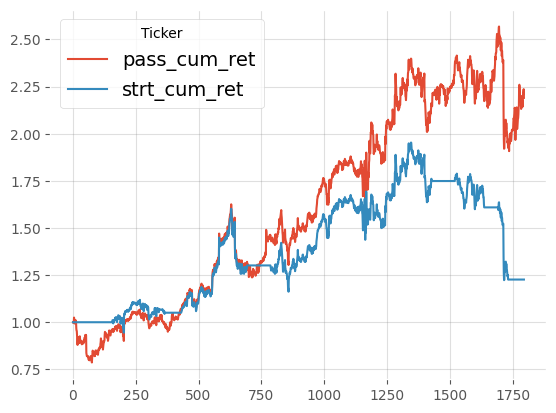

In [44]:
wmt[wmt.columns[-3:-1]].plot()

### <font color = red> Question 7</font>. Please calculate the Sharpe Ratio of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a Sharpe ratio of _________ . 

    Simple moving strategy for WMT leads to a Sharpe ratio of _________ . 

In [45]:
wmt.strt_ret.mean()


np.float64(0.00011375707582524058)

In [46]:
ibm_sharpe = ibm.strt_ret.mean() / ibm.strt_ret.std() * np.sqrt(252)
wmt_sharpe = wmt.strt_ret.mean() / wmt.strt_ret.std() * np.sqrt(252)

In [47]:
wmt

Ticker,Date,WMT,sma_50,sma_200,signal,pass_ret,strt_ret,pass_cum_ret,strt_cum_ret,trade
0,2015-07-29,19.805685,20.079336,21.794393,0,NaN,NaN,NaN,NaN,NaN
1,2015-07-30,19.786491,20.055919,21.788871,0,-0.000970,-0.0,0.999031,1.000000,0.0
2,2015-07-31,19.737123,20.034421,21.782536,0,-0.002498,-0.0,0.996538,1.000000,0.0
3,2015-08-03,19.791973,20.012869,21.780220,0,0.002775,0.0,0.999308,1.000000,0.0
4,2015-08-04,19.811169,19.993072,21.779858,0,0.000969,0.0,1.000277,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...
1790,2022-09-07,43.546246,41.627555,43.840473,0,0.025367,0.0,2.198674,1.226396,0.0
1791,2022-09-08,43.767601,41.721170,43.834505,0,0.005070,0.0,2.209850,1.226396,0.0
1792,2022-09-09,43.899143,41.820291,43.825422,0,0.003001,0.0,2.216492,1.226396,0.0
1793,2022-09-12,44.293736,41.929475,43.816685,0,0.008948,0.0,2.236415,1.226396,0.0


In [48]:

print(f"Simple moving strategy for IBM leads to a Sharpe ratio of {ibm_sharpe:2f} .") 

print(f"Simple moving strategy for WMT leads to a Sharpe ratio of {wmt_sharpe:2f} . ")

Simple moving strategy for IBM leads to a Sharpe ratio of -0.510644 .
Simple moving strategy for WMT leads to a Sharpe ratio of 0.151139 . 


### <font color = red> Question 8</font>. Please calculate the Compound Annual Growth Rate (CAGR) of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a CAGR of _________ .

    Simple moving strategy for WMT leads to a CAGR of _________ .


In [49]:
ibm

Ticker,IBM,sma_20,sma_60,signal,pass_ret,strt_ret,cum_ret,max_cum_ret,max_drawdown
Date,,,,,,,,,
2015-01-07,94.396317,96.620592,99.068448,-1,NaN,NaN,NaN,NaN,NaN
2015-01-08,96.447975,96.481479,98.826420,-1,0.021502,-0.021502,0.978728,0.978728,0.000000
2015-01-09,96.868073,96.438861,98.588572,-1,0.004346,-0.004346,0.974483,0.978728,-0.004337
2015-01-12,95.242523,96.297919,98.344291,-1,-0.016923,0.016923,0.991115,0.991115,0.000000
2015-01-13,95.467804,96.341450,98.123013,-1,0.002363,-0.002363,0.988776,0.991115,-0.002360
...,...,...,...,...,...,...,...,...,...
2022-09-07,113.740059,118.133903,118.805318,-1,0.007782,-0.007782,0.376970,1.636358,-0.769629
2022-09-08,114.416939,117.998975,118.731711,-1,0.005933,-0.005933,0.374740,1.636358,-0.770991
2022-09-09,115.058174,117.849798,118.659848,-1,0.005589,-0.005589,0.372652,1.636358,-0.772268


In [50]:
wmt.strt_cum_ret.iloc[-1]

np.float64(1.2263964991910272)

In [51]:
ibm_cagr = (ibm.cum_ret.iloc[-1] ) ** (252/(len(ibm)-1)) - 1
wmt_cagr = (wmt.strt_cum_ret.iloc[-1]) ** (252 / (len(wmt)-1)) - 1

In [52]:
print(f"Simple moving strategy for IBM leads to a CAGR of {ibm_cagr * 100:2f}% .")

print(f"Simple moving strategy for WMT leads to a CAGR of {wmt_cagr * 100:2f}% .")

Simple moving strategy for IBM leads to a CAGR of -11.895716% .
Simple moving strategy for WMT leads to a CAGR of 2.908163% .


### <font color="green">"Thank you for putting your efforts into the exercise problem sets 💯"</font>